# Phase 4 — Model Comparison

Training data: 2023-24 and 2024-25 seasons (vaastav/Fantasy-Premier-League archive). Test data: the entire 2025-26 season, held out completely during training — a genuine backtest, not an in-sample fit. All rolling/lag features use only gameweeks strictly before the one being predicted (`src/features/historical_features.py`).

In [1]:
import sys
sys.path.insert(0, "..")

import matplotlib.pyplot as plt
import pandas as pd
import psycopg2

from config import settings

conn = psycopg2.connect(settings.DATABASE_URL)
versions = pd.read_sql_query(
    "SELECT DISTINCT ON (model_type, target) model_type, target, mae, rmse, r2, trained_at "
    "FROM model_versions ORDER BY model_type, target, trained_at DESC", conn
)
conn.close()

C:\Users\USER\AppData\Local\Temp\ipykernel_46324\211142045.py:11: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  versions = pd.read_sql_query(


## All trained model variants

In [2]:
for target in ["minutes", "points_per_90", "total_points_direct"]:
    print(f"--- {target} ---")
    display(versions[versions["target"] == target].sort_values("rmse")
            [["model_type", "mae", "rmse", "r2"]])
    print()

--- minutes ---


,model_type,mae,rmse,r2
6,random_forest,13.1964,22.9753,0.6358
9,xgboost,13.2590,23.0333,0.6340
3,linear_regression,13.5706,23.1377,0.6306
0,baseline,15.0242,26.1851,0.5269



--- points_per_90 ---


,model_type,mae,rmse,r2
7,random_forest,7.5539,22.0909,0.0490
4,linear_regression,7.8873,22.1325,0.0454
10,xgboost,7.7148,22.3794,0.0240
1,baseline,6.7317,23.6670,-0.0916



--- total_points_direct ---


,model_type,mae,rmse,r2
8,random_forest,0.9931,1.9708,0.3169
5,linear_regression,1.0064,1.9729,0.3155
11,xgboost,1.0011,1.9855,0.3067
2,baseline,1.0688,2.0863,0.2345


## The key finding: direct beats decomposed

The plan's original design predicted `points_per_90` and `minutes` separately, then combined them (`expected_points = points_per_90_pred * minutes_pred / 90`). That's more interpretable — it separates "how good are they when they play" from "will they play" — but it measurably **underperforms** a single model predicting total points directly:

| Approach | MAE | RMSE | R² |
|---|---|---|---|
| Naive season-average baseline | 1.069 | 2.086 | 0.234 |
| Decomposed (points_per_90 × minutes, both Random Forest) | 1.424 | 2.241 | 0.117 |
| **Direct Random Forest on total_points** | **0.993** | **1.971** | **0.317** |

Why: about 61% of test rows are fringe/unused players with exactly 0 actual minutes. A direct model can learn "this feature profile → 0 points" as one clean pattern. The decomposition has to get *both* a nonzero-biased minutes prediction *and* a nonzero-biased productivity prediction close to zero simultaneously for their product to land near zero — errors compound instead of cancelling. **The direct Random Forest model is the recommended predictor going forward.** The minutes model is still kept and useful in its own right (R²=0.636) for rotation-risk flagging and captaincy-safety checks — just not as a multiplicative input to the points prediction.

## Predicted vs actual, direct model, held-out 2025-26 season

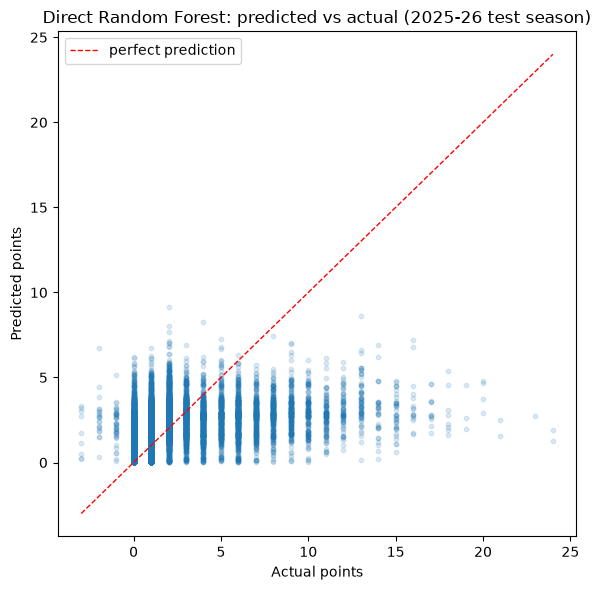

In [3]:
import joblib
from src.features.historical_features import FEATURE_COLS, build_training_frame

df = build_training_frame()
pos_cols = [c for c in df.columns if c.startswith("pos_")]
feature_cols = FEATURE_COLS + pos_cols

test = df[(df["season"] == "2025-26") & (df["gw_number"] > 1)]
X_test = test[feature_cols].fillna(0.0)
y_test = test["target_total_points"]

model = joblib.load("../models/total_points_direct_random_forest.joblib")
pred = model.predict(X_test)

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(y_test, pred, alpha=0.15, s=10)
lims = [min(y_test.min(), pred.min()), max(y_test.max(), pred.max())]
ax.plot(lims, lims, color="red", linewidth=1, linestyle="--", label="perfect prediction")
ax.set_xlabel("Actual points")
ax.set_ylabel("Predicted points")
ax.set_title("Direct Random Forest: predicted vs actual (2025-26 test season)")
ax.legend()
plt.tight_layout()
plt.show()

## Feature importance

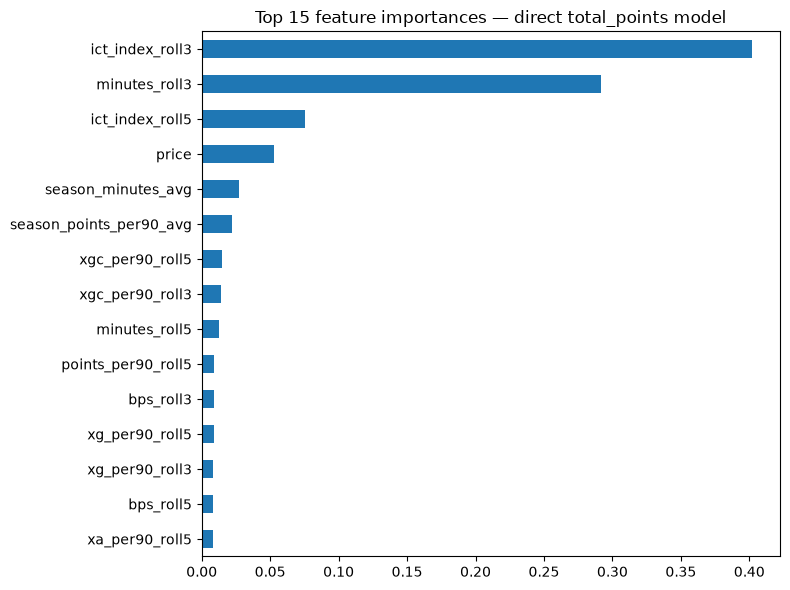

In [4]:
importances = pd.Series(model.feature_importances_, index=feature_cols).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 6))
importances.head(15)[::-1].plot.barh(ax=ax)
ax.set_title("Top 15 feature importances \u2014 direct total_points model")
plt.tight_layout()
plt.show()

## Next steps

Phase 5 applies this trained model to our own live 2026/27 data (not the historical archive) to actually generate transfer/captaincy/bench recommendations for the real team — that requires building the same feature set from `player_gameweek_stats` that this model was trained on, which is the next piece of work.